In [5]:
# === Full script: evaluate 5 anomaly detectors × multiple ML regressors,
# === rank all combinations, and print separate anomaly & model ranks ===

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

# Anomaly detectors
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from sklearn.decomposition import PCA

# Regressors
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
)
from sklearn.linear_model import LinearRegression, Ridge, BayesianRidge, HuberRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
)

# -----------------------------
# 1) Load & basic feature prep
# -----------------------------
PATH = r"C:\Users\israt\HD lab\My Project\Dataset\Airsage Dataset\NebraskaLakes_Cleaned_round.csv"
df = pd.read_csv(PATH, low_memory=False)

df["date"] = pd.to_datetime(df["date"], format="%Y%m%d", errors="coerce")
df["count"] = pd.to_numeric(df["count"], errors="coerce")      # target (y)
df["duration"] = pd.to_numeric(df["duration"], errors="coerce")

df = df.dropna(subset=["date", "count", "duration"]).copy()

# Calendar features
df["month"] = df["date"].dt.month
df["dow"] = df["date"].dt.dayofweek
df["is_weekend"] = (df["dow"] >= 5).astype(int)

# Build numeric feature matrix X (exclude the target!)
feat_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in {"count", "anomaly_label", "anomaly_score"}  # ensure no leakage columns
]
X_all = df[feat_cols].fillna(0).to_numpy(dtype=np.float32)
y_all = df["count"].to_numpy(dtype=np.float32)

# Optional: create a stratification label using IF on X_all (no target leakage)
scaler_gate = StandardScaler().fit(X_all)
Z_gate = scaler_gate.transform(X_all)
gate = IsolationForest(contamination=0.10, random_state=42).fit(Z_gate)
gate_y = (gate.predict(Z_gate) == -1).astype(int)

# Split
X_tr, X_te, y_tr, y_te, gate_y_tr, gate_y_te = train_test_split(
    X_all, y_all, gate_y, test_size=0.2, random_state=42, stratify=gate_y
)

# ---------------------------------
# 2) Define models & pretty names
# ---------------------------------
candidates = [
    ("RF",    RandomForestRegressor(n_estimators=600, max_depth=None,
                                    min_samples_split=2, min_samples_leaf=1,
                                    max_features="sqrt", n_jobs=-1, random_state=42)),
    ("XGB",   XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                           subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                           n_jobs=-1, random_state=42, tree_method="hist")),
    ("ETR",   ExtraTreesRegressor(n_estimators=600, max_depth=None,
                                  min_samples_leaf=1, max_features="sqrt",
                                  n_jobs=-1, random_state=42)),
    ("DT",    DecisionTreeRegressor(max_depth=12, random_state=42)),
    ("LR",    LinearRegression()),
    ("RIDGE", Ridge(alpha=1.0, random_state=42)),
    ("BAYES", BayesianRidge()),
    ("HUBER", HuberRegressor(epsilon=1.35)),
]

anom_detectors = {
    "IF":    IsolationForest(contamination=0.10, random_state=42),
    "LOF":   LocalOutlierFactor(n_neighbors=35, novelty=True),
    "OCSVM": OneClassSVM(kernel="rbf", gamma="scale", nu=0.10),
    "ELLIP": EllipticEnvelope(contamination=0.10, random_state=42),
    "PCA":   "PCA_RECON",  # special case handled below
}

anom_full = {
    "IF":    "IsolationForest",
    "LOF":   "LocalOutlierFactor (novelty)",
    "OCSVM": "One-Class SVM (RBF)",
    "ELLIP": "EllipticEnvelope",
    "PCA":   "PCA Reconstruction Error",
}
model_full = {
    "RF":    "RandomForestRegressor",
    "XGB":   "XGBRegressor",
    "ETR":   "ExtraTreesRegressor",
    "DT":    "DecisionTreeRegressor",
    "LR":    "LinearRegression",
    "RIDGE": "Ridge",
    "BAYES": "BayesianRidge",
    "HUBER": "HuberRegressor",
}

# ----------------------------------------------------
# 3) Helper to fit detector and produce scores/labels
# ----------------------------------------------------
def fit_anom_and_score(name, det, Xtr, Xte, contam=0.10):
    """
    Returns:
      score_tr, score_te, label_tr, label_te
    Scores: higher = more anomalous.
    Labels: top-contam fraction of TRAIN scores are labeled 1 (anomaly).
    """
    scaler = StandardScaler().fit(Xtr)
    A_tr = scaler.transform(Xtr)
    A_te = scaler.transform(Xte)

    if name == "PCA":
        pca = PCA(n_components=0.95, svd_solver="full", random_state=42).fit(A_tr)
        R_tr = pca.inverse_transform(pca.transform(A_tr))
        R_te = pca.inverse_transform(pca.transform(A_te))
        score_tr = ((A_tr - R_tr) ** 2).mean(axis=1)
        score_te = ((A_te - R_te) ** 2).mean(axis=1)
    else:
        d = clone(det)
        d.fit(A_tr)
        if hasattr(d, "score_samples"):
            s_tr = d.score_samples(A_tr)
            s_te = d.score_samples(A_te)
        elif hasattr(d, "decision_function"):
            s_tr = d.decision_function(A_tr)
            s_te = d.decision_function(A_te)
        else:
            s_tr = d.predict(A_tr).astype(float)
            s_te = d.predict(A_te).astype(float)
        score_tr = -s_tr  # convert to "higher = more anomalous"
        score_te = -s_te

    thr = np.quantile(score_tr, 1.0 - contam)
    label_tr = (score_tr >= thr).astype(int)
    label_te = (score_te >= thr).astype(int)
    return score_tr.astype(np.float32), score_te.astype(np.float32), label_tr, label_te

# -------------------------------------------------------
# 4) Evaluate all anomaly × model pairs and rank results
# -------------------------------------------------------
TH_Q = 0.50                                     # quantile for classification-style threshold on y
TH = float(np.quantile(y_tr, TH_Q))

combo_rows = []

for an_key, det in anom_detectors.items():
    s_tr, s_te, l_tr, l_te = fit_anom_and_score(an_key, det, X_tr, X_te, contam=0.10)

    # Augment features with this detector's outputs
    Xtr_aug = np.c_[X_tr, l_tr.astype(np.float32), s_tr.astype(np.float32)]
    Xte_aug = np.c_[X_te, l_te.astype(np.float32), s_te.astype(np.float32)]

    for mdl_key, mdl in candidates:
        m = clone(mdl)
        m.fit(Xtr_aug, y_tr)
        pred = m.predict(Xte_aug)

        # Regression metrics
        r2  = r2_score(y_te, pred)
        mae = mean_absolute_error(y_te, pred)

        # Classification-style metrics via threshold on y/pred
        y_true = (y_te > TH).astype(int)
        y_hat  = (pred  > TH).astype(int)

        P  = precision_score(y_true, y_hat, zero_division=0)
        R  = recall_score(y_true, y_hat, zero_division=0)
        F1 = f1_score(y_true, y_hat, zero_division=0)
        PR = average_precision_score(y_true, pred)

        combo_rows.append({
            "Anomaly": an_key,
            "AnomalyName": anom_full.get(an_key, an_key),
            "Model": mdl_key,
            "ModelName": model_full.get(mdl_key, mdl_key),
            "P": P, "R": R, "F1": F1, "PR_AUC": PR, "R2": r2, "MAE": mae
        })

combo_rank = (
    pd.DataFrame(combo_rows)
      .sort_values(["F1", "PR_AUC", "R2", "MAE", "P", "R"],
                   ascending=[False, False, False, True, False, False])
      .reset_index(drop=True)
)
combo_rank["rank_pos"] = combo_rank.index + 1  # 1 = best

print("\n=== ALL COMBINATIONS ranked (best first) ===")
print(
    combo_rank[["rank_pos","Anomaly","AnomalyName","Model","ModelName","F1","PR_AUC","R2","MAE","P","R"]]
    .head(30)
    .to_string(index=False, float_format=lambda x: f"{x:.3f}")
)

# -------------------------------------------------------
# 5) Top-3 mapping (per-anomaly bests + 3×3 cartesian)
# -------------------------------------------------------
# Top-3 anomalies by their best achievable rank
anom_best = (
    combo_rank.groupby(["Anomaly","AnomalyName"], as_index=False)["rank_pos"]
              .min()
              .sort_values("rank_pos")
)
top3_anoms = anom_best.head(3)[["Anomaly","AnomalyName"]].values.tolist()
print("\nTop-3 anomaly detectors (by best combo):",
      [f"{a} — {aname}" for a, aname in top3_anoms])

# For each top anomaly, list its top-3 models
print("\n=== Top-3 models within each top anomaly ===")
for a, aname in top3_anoms:
    sub = combo_rank[combo_rank["Anomaly"] == a].head(3)
    print(f"\n[{a}] {aname}")
    print(
        sub[["Model","ModelName","F1","PR_AUC","R2","MAE","P","R"]]
        .to_string(index=False, float_format=lambda x: f"{x:.3f}")
    )

# Models by average rank (stable)
model_avg_rank = (
    combo_rank.groupby(["Model","ModelName"], as_index=False)["rank_pos"].mean()
              .sort_values("rank_pos")
)
top3_models = model_avg_rank.head(3)[["Model","ModelName"]].values.tolist()
print("\nTop-3 models (by average rank):",
      [f"{m} — {mname}" for m, mname in top3_models])

# 3×3 cartesian mapping
cart = combo_rank[
    combo_rank["Anomaly"].isin([a for a,_ in top3_anoms]) &
    combo_rank["Model"].isin([m for m,_ in top3_models])
].sort_values(["Anomaly","rank_pos"])
print("\n=== 3×3 mapping (top anomalies × top models) ===")
print(
    cart[["Anomaly","AnomalyName","Model","ModelName","F1","PR_AUC","R2","MAE","P","R"]]
    .to_string(index=False, float_format=lambda x: f"{x:.3f}")
)

# -------------------------------------------------------
# 6) Separate aggregated ranks: Anomaly rank & Model rank
# -------------------------------------------------------
# Anomaly ranks
anom_stats = (
    combo_rank
    .groupby(["Anomaly","AnomalyName"], as_index=False)
    .agg(
        best_rank=("rank_pos","min"),
        avg_rank=("rank_pos","mean"),
        median_rank=("rank_pos","median"),
        n=("rank_pos","size"),
    )
)
idx_best_anom = combo_rank.groupby("Anomaly")["rank_pos"].idxmin()
anom_best_rows = combo_rank.loc[idx_best_anom,
    ["Anomaly","AnomalyName","Model","ModelName","F1","PR_AUC","R2","MAE","rank_pos"]
].rename(columns={"rank_pos":"best_rank_check"})
anom_rank = (
    anom_stats.merge(anom_best_rows, on=["Anomaly","AnomalyName"])
              .sort_values(["best_rank","avg_rank"], ascending=[True, True])
              .reset_index(drop=True)
)

print("\n=== ANOMALY DETECTOR RANKS ===")
print(
    anom_rank[[
        "Anomaly","AnomalyName","best_rank","avg_rank","median_rank","n",
        "Model","ModelName","F1","PR_AUC","R2","MAE"
    ]].to_string(index=False, float_format=lambda x: f"{x:.3f}")
)




# ---------------------------
# Notes:
# - Adjust TH_Q (e.g., 0.75) if F1/PR-AUC are saturated near 1.0.
# - Change contamination in detectors to match your domain (default 0.10).
# - Features are augmented with [anom_label, anom_score] per detector.
# ---------------------------


c:\Users\israt\miniconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.86967e-10): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\israt\miniconda3\Lib\site-packages\sklearn\linear_model\_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\Users\israt\miniconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=6.88953e-09): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\israt\miniconda3\Lib\site-packages\sklearn\linear_model\_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP


=== ALL COMBINATIONS ranked (best first) ===
 rank_pos Anomaly                  AnomalyName Model             ModelName    F1  PR_AUC    R2    MAE     P     R
        1   ELLIP             EllipticEnvelope    RF RandomForestRegressor 0.993   1.000 0.994  4.769 0.988 0.998
        2   OCSVM          One-Class SVM (RBF)   ETR   ExtraTreesRegressor 0.993   1.000 0.995  4.365 0.988 0.998
        3     PCA     PCA Reconstruction Error   ETR   ExtraTreesRegressor 0.993   1.000 0.996  4.060 0.987 0.998
        4   ELLIP             EllipticEnvelope   ETR   ExtraTreesRegressor 0.993   1.000 0.995  4.271 0.987 0.998
        5     PCA     PCA Reconstruction Error    RF RandomForestRegressor 0.992   1.000 0.995  4.614 0.987 0.997
        6      IF              IsolationForest   ETR   ExtraTreesRegressor 0.992   1.000 0.996  4.285 0.986 0.998
        7     LOF LocalOutlierFactor (novelty)    RF RandomForestRegressor 0.992   1.000 0.994  4.639 0.987 0.997
        8     LOF LocalOutlierFactor (nove

c:\Users\israt\miniconda3\Lib\site-packages\sklearn\linear_model\_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [4]:
# === SIMPLE: rank (Anomaly × Model) by F1, PR_AUC, R2, MAE, P, R ===
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

# anomaly detectors
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from sklearn.decomposition import PCA

# regressors
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression, Ridge, BayesianRidge, HuberRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

# metrics
from sklearn.metrics import r2_score, mean_absolute_error, precision_score, recall_score, f1_score, average_precision_score

# ---------------- data (minimal) ----------------
PATH = r"C:\Users\israt\HD lab\My Project\Dataset\Airsage Dataset\NebraskaLakes_Cleaned_round.csv"
df = pd.read_csv(PATH, low_memory=False)
df["date"] = pd.to_datetime(df["date"], format="%Y%m%d", errors="coerce")
df["count"] = pd.to_numeric(df["count"], errors="coerce")
df["duration"] = pd.to_numeric(df["duration"], errors="coerce")
df = df.dropna(subset=["date","count","duration"]).copy()
df["month"] = df["date"].dt.month
df["dow"] = df["date"].dt.dayofweek
df["is_weekend"] = (df["dow"] >= 5).astype(int)

feat_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in {"count","anomaly_label","anomaly_score"}]
X = df[feat_cols].fillna(0).to_numpy(np.float32)
y = df["count"].to_numpy(np.float32)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
TH = float(np.quantile(y_tr, 0.50))  # median threshold for classification-style metrics
CONTAM = 0.10
TOPN = 5

# ---------------- configs ----------------
anom = {
    "IF":    (IsolationForest(contamination=CONTAM, random_state=42), "IsolationForest"),
    "LOF":   (LocalOutlierFactor(n_neighbors=35, novelty=True),       "LocalOutlierFactor (novelty)"),
    "OCSVM": (OneClassSVM(kernel="rbf", gamma="scale", nu=CONTAM),    "One-Class SVM (RBF)"),
    "ELLIP": (EllipticEnvelope(contamination=CONTAM, random_state=42),"EllipticEnvelope"),
    "PCA":   ("PCA_RECON",                                            "PCA Reconstruction Error"),
}
models = {
    "RF":    (RandomForestRegressor(n_estimators=600, max_features="sqrt", n_jobs=-1, random_state=42), "RandomForestRegressor"),
    "XGB":   (XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8,
                           reg_lambda=1.0, n_jobs=-1, random_state=42, tree_method="hist"),             "XGBRegressor"),
    "ETR":   (ExtraTreesRegressor(n_estimators=600, max_features="sqrt", n_jobs=-1, random_state=42),   "ExtraTreesRegressor"),
    "DT":    (DecisionTreeRegressor(max_depth=12, random_state=42),                                     "DecisionTreeRegressor"),
    "LR":    (LinearRegression(),                                                                        "LinearRegression"),
    "RIDGE": (Ridge(alpha=1.0, random_state=42),                                                         "Ridge"),
    "BAYES": (BayesianRidge(),                                                                           "BayesianRidge"),
    "HUBER": (HuberRegressor(epsilon=1.35),                                                              "HuberRegressor"),
}

# ---------------- helper ----------------
def anom_scores(code, det, Xtr, Xte, contam=0.10):
    S = StandardScaler().fit(Xtr)
    A_tr, A_te = S.transform(Xtr), S.transform(Xte)
    if code == "PCA":
        p = PCA(n_components=0.95, svd_solver="full", random_state=42).fit(A_tr)
        R_tr, R_te = p.inverse_transform(p.transform(A_tr)), p.inverse_transform(p.transform(A_te))
        s_tr = ((A_tr - R_tr)**2).mean(1); s_te = ((A_te - R_te)**2).mean(1)
    else:
        d = clone(det).fit(A_tr)
        if hasattr(d,"score_samples"): ss_tr, ss_te = d.score_samples(A_tr), d.score_samples(A_te)
        elif hasattr(d,"decision_function"): ss_tr, ss_te = d.decision_function(A_tr), d.decision_function(A_te)
        else: ss_tr, ss_te = d.predict(A_tr).astype(float), d.predict(A_te).astype(float)
        s_tr, s_te = -ss_tr, -ss_te
    thr = np.quantile(s_tr, 1.0 - contam)
    return s_tr.astype(np.float32), s_te.astype(np.float32), (s_tr>=thr).astype(int), (s_te>=thr).astype(int)

# ---------------- evaluate + rank ----------------
rows = []
for akey, (adet, aname) in anom.items():
    s_tr, s_te, l_tr, l_te = anom_scores(akey, adet, X_tr, X_te, CONTAM)
    Xtr_aug = np.c_[X_tr, l_tr.astype(np.float32), s_tr]
    Xte_aug = np.c_[X_te, l_te.astype(np.float32), s_te]
    for mkey, (mdl, mname) in models.items():
        m = clone(mdl).fit(Xtr_aug, y_tr)
        pred = m.predict(Xte_aug)
        r2, mae = r2_score(y_te, pred), mean_absolute_error(y_te, pred)
        y_true, y_hat = (y_te > TH).astype(int), (pred > TH).astype(int)
        P, R = precision_score(y_true, y_hat, zero_division=0), recall_score(y_true, y_hat, zero_division=0)
        F1, PR = f1_score(y_true, y_hat, zero_division=0), average_precision_score(y_true, pred)
        rows.append(dict(Anomaly=akey, AnomalyName=aname, Model=mkey, ModelName=mname,
                         F1=F1, PR_AUC=PR, R2=r2, MAE=mae, P=P, R=R))


rank = (pd.DataFrame(rows)
          .sort_values(["F1","PR_AUC","R2","MAE","P","R"],
                       ascending=[False, False, False, True, False, False])
          .reset_index(drop=True))
rank["rank_pos"] = rank.index + 1

#print("\n=== RANKED (ALL Anomaly + Model) ===")
cols = ["rank_pos","Anomaly","AnomalyName","Model","ModelName","F1","PR_AUC","R2","MAE","P","R"]

# show every row, even if long
#pd.set_option("display.max_rows", None)
#pd.set_option("display.width", None)

print(rank[cols].to_string(index=False, float_format=lambda x: f"{x:.3f}"))


print("\n=== RANKED (Anomaly + Model) ===")
print(rank[["rank_pos","Anomaly","AnomalyName","Model","ModelName","F1","PR_AUC","R2","MAE","P","R"]]
      .head(TOPN).to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# Tip: If F1/PR_AUC saturate near 1.0, try TH = np.quantile(y_tr, 0.75) or sort only by ["MAE","R2"].


c:\Users\israt\miniconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.92569e-10): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\israt\miniconda3\Lib\site-packages\sklearn\linear_model\_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\Users\israt\miniconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=7.47863e-09): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\israt\miniconda3\Lib\site-packages\sklearn\linear_model\_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP

 rank_pos Anomaly                  AnomalyName Model             ModelName    F1  PR_AUC     R2     MAE     P     R
        1     LOF LocalOutlierFactor (novelty) RIDGE                 Ridge 0.993   1.000  1.000   0.290 0.987 1.000
        2   ELLIP             EllipticEnvelope RIDGE                 Ridge 0.993   1.000  1.000   0.291 0.987 1.000
        3     PCA     PCA Reconstruction Error RIDGE                 Ridge 0.993   1.000  1.000   0.294 0.987 1.000
        4     LOF LocalOutlierFactor (novelty) BAYES         BayesianRidge 0.993   1.000  1.000   0.214 0.987 1.000
        5      IF              IsolationForest BAYES         BayesianRidge 0.993   1.000  1.000   0.215 0.987 1.000
        6     PCA     PCA Reconstruction Error BAYES         BayesianRidge 0.993   1.000  1.000   0.203 0.987 1.000
        7   ELLIP             EllipticEnvelope   ETR   ExtraTreesRegressor 0.993   1.000  0.982   4.967 0.988 0.999
        8   OCSVM          One-Class SVM (RBF) BAYES         BayesianRid

c:\Users\israt\miniconda3\Lib\site-packages\sklearn\linear_model\_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [3]:
# ==== Compare WITH anomalies vs AFTER DROPPING anomalies (same output structure) ====
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score, mean_absolute_error,
    precision_score, recall_score, f1_score, average_precision_score
)
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    IsolationForest, RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor,
    VotingRegressor, StackingRegressor
)
from sklearn.linear_model import LinearRegression, Ridge, BayesianRidge, HuberRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

# ---------- 0) Load + minimal features ----------
PATH = r"C:\Users\israt\HD lab\My Project\Dataset\Airsage Dataset\NebraskaLakes_Cleaned_round.csv"
df = pd.read_csv(PATH, low_memory=False)

df["date"] = pd.to_datetime(df["date"], format="%Y%m%d", errors="coerce")
df["count"] = pd.to_numeric(df["count"], errors="coerce")      # target
df["duration"] = pd.to_numeric(df["duration"], errors="coerce")
df = df.dropna(subset=["date","count","duration"]).copy()

# simple time features
df["month"] = df["date"].dt.month
df["dow"] = df["date"].dt.dayofweek
df["is_weekend"] = (df["dow"] >= 5).astype(int)

feat_cols = [c for c in df.select_dtypes(include=[np.number]).columns
             if c not in {"count","anomaly_label","anomaly_score"}]
X_all = df[feat_cols].fillna(0).to_numpy(np.float32)
y_all = df["count"].to_numpy(np.float32)

# ---------- 1) Models to evaluate ----------
candidates = [
    ("rf",    RandomForestRegressor(n_estimators=600, max_depth=None,
                                    min_samples_split=2, min_samples_leaf=1,
                                    max_features="sqrt", n_jobs=-1, random_state=42)),
    ("xgb",   XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                           subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                           n_jobs=-1, random_state=42, tree_method="hist")),
    ("etr",   ExtraTreesRegressor(n_estimators=600, max_depth=None,
                                  min_samples_leaf=1, max_features="sqrt",
                                  n_jobs=-1, random_state=42)),
    ("gbr",   GradientBoostingRegressor(random_state=42, n_estimators=300, learning_rate=0.05, max_depth=3)),
    ("dt",    DecisionTreeRegressor(max_depth=12, random_state=42)),
    ("lr",    LinearRegression()),
    ("ridge", Ridge(alpha=1.0, random_state=42)),
    ("bayes", BayesianRidge()),
    ("huber", HuberRegressor(epsilon=1.35)),
]

# ---------- 2) Helper: rank models on one split ----------
def rank_models_on_split(X_tr, X_te, y_tr, y_te, candidates, label):
    TH = float(np.median(y_tr))  # threshold for P/R/F1/PR-AUC
    rows, fitted = [], {}
    for name, mdl in candidates:
        m = clone(mdl)
        m.fit(X_tr, y_tr)
        fitted[name] = m
        pred = m.predict(X_te)

        r2  = r2_score(y_te, pred)
        mae = mean_absolute_error(y_te, pred)

        y_true = (y_te > TH).astype(int)
        y_hat  = (pred  > TH).astype(int)

        P  = precision_score(y_true, y_hat, zero_division=0)
        R  = recall_score(y_true, y_hat, zero_division=0)
        F1 = f1_score(y_true, y_hat, zero_division=0)
        PR = average_precision_score(y_true, pred)

        rows.append({"Scenario": label, "Model": name.upper(),
                     "P": P, "R": R, "F1": F1, "PR_AUC": PR, "R2": r2, "MAE": mae})

    rank_df = (pd.DataFrame(rows)
                 .sort_values(["F1","PR_AUC","R2","MAE","P","R"],
                              ascending=[False,False,False,True,False,False])
                 .reset_index(drop=True))
    return rank_df

# ---------- 3) Scenario A: WITH anomalies (no drop) ----------
X_tr_A, X_te_A, y_tr_A, y_te_A = train_test_split(X_all, y_all, test_size=0.2, random_state=42)
rank_with = rank_models_on_split(X_tr_A, X_te_A, y_tr_A, y_te_A, candidates, label="WITH_ANOMALIES")

# ---------- 4) Scenario B: AFTER DROPPING anomalies (IsolationForest prefilter) ----------
PREFILTER_CONTAM = 0.10
Z = StandardScaler().fit_transform(X_all)  # unsupervised, no target leakage
gate = IsolationForest(contamination=PREFILTER_CONTAM, random_state=42).fit(Z)
keep_mask = (gate.predict(Z) == 1)  # 1=normal, -1=anomaly
X_clean, y_clean = X_all[keep_mask], y_all[keep_mask]

print(f"Dropped {len(y_all) - len(y_clean)} anomalies "
      f"({100*(1 - len(y_clean)/len(y_all)):.1f}%) using IsolationForest prefilter.")

X_tr_B, X_te_B, y_tr_B, y_te_B = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)
rank_wo = rank_models_on_split(X_tr_B, X_te_B, y_tr_B, y_te_B, candidates, label="NO_ANOMALIES")

# ---------- 5) Print BOTH tables (identical structure) ----------
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)

print("\n=== RANKED (WITH anomalies) ===")
print(rank_with[["Model","P","R","F1","PR_AUC","R2","MAE"]]
      .to_string(index=False, float_format=lambda x: f"{x:.3f}"))

print("\n=== RANKED (AFTER DROPPING anomalies) ===")
print(rank_wo[["Model","P","R","F1","PR_AUC","R2","MAE"]]
      .to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# ---------- 6) Optional: side-by-side comparison by Model ----------
cmp = (rank_with.merge(rank_wo, on="Model", suffixes=("_WITH","_NOANOM"))
               .loc[:, ["Model",
                        "F1_WITH","F1_NOANOM",
                        "PR_AUC_WITH","PR_AUC_NOANOM",
                        "R2_WITH","R2_NOANOM",
                        "MAE_WITH","MAE_NOANOM",
                        "P_WITH","P_NOANOM","R_WITH","R_NOANOM"]])

print("\n=== SIDE-BY-SIDE (same models) ===")
print(cmp.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# ---------- 7) Ensembles (Top-3) + Top-3 hybrid avg ----------
# Take Top-3 models from NO_ANOMALIES ranking
top3_noanom = rank_wo["Model"].head(3).tolist()   # e.g., ["XGB","RF","ETR"]
top3 = list(dict.fromkeys(top3_noanom))
assert len(top3) == 3, f"Expected 3 unique models in top3, got {top3}"

# We'll ensemble on the NO_ANOMALIES split
X_tr, X_te, y_tr, y_te = X_tr_B, X_te_B, y_tr_B, y_te_B

# Map model name -> estimator from `candidates` (uppercase keys)
cand_map = {name.upper(): est for name, est in candidates}
for nm in top3:
    assert nm in cand_map, f"{nm} not in candidates: {list(cand_map)}"

# Base learners for ensembles (must be uppercase names)
bases = [(nm, clone(cand_map[nm])) for nm in top3]

# Small cache of fitted base candidates (keys are original names: 'rf','xgb',...)
fitted = {name: clone(est).fit(X_tr, y_tr) for name, est in candidates}

# Voting (equal weights across Top-3)
vote = VotingRegressor(bases).fit(X_tr, y_tr)
pred_vote = vote.predict(X_te)

# Stacking with several meta-learners
stack_lin = StackingRegressor(
    estimators=bases,
    final_estimator=LinearRegression(),
    cv=3, passthrough=True
).fit(X_tr, y_tr)
pred_stack_lin = stack_lin.predict(X_te)

stack_ridge = StackingRegressor(
    estimators=bases,
    final_estimator=Ridge(alpha=1.0, random_state=42),
    cv=3, passthrough=True
).fit(X_tr, y_tr)
pred_stack_ridge = stack_ridge.predict(X_te)

stack_gbr = StackingRegressor(
    estimators=bases,
    final_estimator=GradientBoostingRegressor(random_state=42, n_estimators=200, learning_rate=0.05, max_depth=3),
    cv=3, passthrough=True
).fit(X_tr, y_tr)
pred_stack_gbr = stack_gbr.predict(X_te)

# ---- Hybrid (Top-3 equal-weight average) ----
def _predict_from_name(nm_upper: str):
    key_l = nm_upper.lower()
    if key_l in fitted:
        return fitted[key_l].predict(X_te)
    return clone(cand_map[nm_upper]).fit(X_tr, y_tr).predict(X_te)

_top3_preds = [_predict_from_name(nm) for nm in top3]     # e.g., preds from ["XGB","RF","ETR"]
pred_avg = np.mean(np.column_stack(_top3_preds), axis=1)

# ---------- 8) Report ----------
def show(name, yt, yp):
    print(f"{name:<24} R2={r2_score(yt, yp):.4f}  MAE={mean_absolute_error(yt, yp):.4f}")

print("\n=== Ensembles with Top-3 bases (NO_ANOMALIES split) ===")
show("Voting (Top-3, equal)", y_te, pred_vote)
show("Stack (Linear meta)",   y_te, pred_stack_lin)
show("Stack (Ridge meta)",    y_te, pred_stack_ridge)
show("Stack (GBR meta)",      y_te, pred_stack_gbr)
show("Hybrid (Top-3 avg)",    y_te, pred_avg)


c:\Users\israt\miniconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=7.43592e-09): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\israt\miniconda3\Lib\site-packages\sklearn\linear_model\_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Dropped 12363 anomalies (10.0%) using IsolationForest prefilter.


c:\Users\israt\miniconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=5.63311e-09): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\israt\miniconda3\Lib\site-packages\sklearn\linear_model\_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)



=== RANKED (WITH anomalies) ===
Model     P     R    F1  PR_AUC    R2   MAE
  ETR 0.988 0.999 0.993   1.000 0.982 4.731
   RF 0.987 0.998 0.993   1.000 0.981 5.373
RIDGE 0.986 0.998 0.992   1.000 1.000 0.593
BAYES 0.985 0.998 0.991   1.000 1.000 0.652
  GBR 0.995 0.984 0.989   0.999 0.991 7.001
  XGB 0.988 0.988 0.988   0.999 0.986 5.910
   LR 0.979 0.995 0.987   0.999 0.999 3.272
HUBER 0.983 0.987 0.985   0.999 0.998 5.448
   DT 0.974 0.978 0.976   0.995 0.981 9.803

=== RANKED (AFTER DROPPING anomalies) ===
Model     P     R    F1  PR_AUC    R2   MAE
BAYES 0.980 0.999 0.990   1.000 1.000 0.082
  ETR 0.979 0.999 0.989   1.000 0.998 1.210
  GBR 0.988 0.990 0.989   1.000 0.999 1.639
RIDGE 0.978 0.999 0.989   1.000 1.000 0.077
   RF 0.978 0.999 0.988   1.000 0.998 1.387
  XGB 0.981 0.995 0.988   0.999 0.999 1.348
   DT 0.966 0.982 0.974   0.996 0.997 2.702
HUBER 0.974 0.968 0.971   0.996 0.993 3.860
   LR 0.948 0.982 0.965   0.996 0.996 3.784

=== SIDE-BY-SIDE (same models) ===
Model  F

c:\Users\israt\miniconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=5.63311e-09): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\israt\miniconda3\Lib\site-packages\sklearn\linear_model\_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)



=== Ensembles with Top-3 bases (NO_ANOMALIES split) ===
Voting (Top-3, equal)    R2=0.9997  MAE=0.8199
Stack (Linear meta)      R2=0.9999  MAE=0.1302
Stack (Ridge meta)       R2=0.9999  MAE=0.1284
Stack (GBR meta)         R2=1.0000  MAE=0.3698
Hybrid (Top-3 avg)       R2=0.9997  MAE=0.8199


In [4]:
top3_noanom = rank_wo["Model"].head(3).tolist()
print(f"\nTop-3 to stack (NO_ANOMALIES): {top3_noanom}")



Top-3 to stack (NO_ANOMALIES): ['BAYES', 'ETR', 'GBR']


In [20]:
# ---- 5) Ensembles (Top-3) + simple hybrid + meta_models ----
from sklearn.ensemble import VotingRegressor, StackingRegressor  # new

# We'll ensemble on the NO_ANOMALIES split
X_tr, X_te, y_tr, y_te = X_tr_B, X_te_B, y_tr_B, y_te_B

# Use the NO_ANOMALIES top-3 ranking
top3 = list(dict.fromkeys(top3_noanom))
assert len(top3) == 3, f"Expected 3 unique models in top3, got {top3}"

# Map model name -> estimator from `candidates` (uppercase keys)
cand_map = {name.upper(): est for name, est in candidates}
for nm in top3:
    assert nm in cand_map, f"{nm} not in candidates"

# Base learners for ensembles (names must match `top3`)
bases = [(nm, clone(cand_map[nm])) for nm in top3]

# Fit a small 'fitted' cache for hybrid fallback (keys are original candidate names, e.g., 'rf','xgb',...)
fitted = {name: clone(est).fit(X_tr, y_tr) for name, est in candidates}

# Voting (equal weights across Top-3)
vote = VotingRegressor(bases).fit(X_tr, y_tr)
pred_vote = vote.predict(X_te)

# Stacking with a few meta models
stack_lin = StackingRegressor(
    estimators=bases,
    final_estimator=LinearRegression(),
    cv=3,
    passthrough=True
).fit(X_tr, y_tr)
pred_stack_lin = stack_lin.predict(X_te)

stack_ridge = StackingRegressor(
    estimators=bases,
    final_estimator=Ridge(alpha=1.0, random_state=42),
    cv=3,
    passthrough=True
).fit(X_tr, y_tr)
pred_stack_ridge = stack_ridge.predict(X_te)

stack_gbr = StackingRegressor(
    estimators=bases,
    final_estimator=GradientBoostingRegressor(random_state=42, n_estimators=200, learning_rate=0.05, max_depth=3),
    cv=3,
    passthrough=True
).fit(X_tr, y_tr)
pred_stack_gbr = stack_gbr.predict(X_te)

# Simple hybrid (equal-weight average) — safe fallback if base preds missing
_rf_pred  = fitted["rf"].predict(X_te)  if "rf"  in fitted else clone(cand_map["RF"]).fit(X_tr, y_tr).predict(X_te)
_xgb_pred = fitted["xgb"].predict(X_te) if "xgb" in fitted else clone(cand_map["XGB"]).fit(X_tr, y_tr).predict(X_te)
pred_avg = 0.5 * _rf_pred + 0.5 * _xgb_pred

meta_models = {
    "Linear":           LinearRegression(),
    "Ridge":            Ridge(alpha=1.0, random_state=42),
    "BayesianRidge":    BayesianRidge(),
    "GBR":              GradientBoostingRegressor(random_state=42, n_estimators=300, learning_rate=0.05, max_depth=3),
    "DecisionTree":     DecisionTreeRegressor(random_state=42, max_depth=8),
    "RandomForest":     RandomForestRegressor(random_state=42, n_estimators=300, max_depth=12, n_jobs=-1),
    "XGB":              XGBRegressor(random_state=42, n_estimators=400, max_depth=3, learning_rate=0.1,
                                     subsample=0.9, colsample_bytree=0.9, n_jobs=-1, tree_method="hist"),
}

# ---- 6) Report ----
def show(name, yt, yp):
    print(f"{name:<24} R2={r2_score(yt, yp):.4f}  MAE={mean_absolute_error(yt, yp):.4f}")

print("\n=== Ensembles with Top-3 bases (NO_ANOMALIES split) ===")
show("Voting (Top-3, equal)", y_te, pred_vote)
show("Stack (Linear meta)",   y_te, pred_stack_lin)
show("Stack (Ridge meta)",    y_te, pred_stack_ridge)
show("Stack (GBR meta)",      y_te, pred_stack_gbr)
show("Hybrid RF+XGB (avg)",   y_te, pred_avg)


c:\Users\israt\miniconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=5.63311e-09): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\israt\miniconda3\Lib\site-packages\sklearn\linear_model\_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)



=== Ensembles with Top-3 bases (NO_ANOMALIES split) ===
Voting (Top-3, equal)    R2=0.9997  MAE=0.8199
Stack (Linear meta)      R2=0.9999  MAE=0.1302
Stack (Ridge meta)       R2=0.9999  MAE=0.1284
Stack (GBR meta)         R2=1.0000  MAE=0.3698
Hybrid RF+XGB (avg)      R2=0.9991  MAE=1.1708


In [2]:
# ---------- 9) Sample rows with POI/DATE — Actual vs Predicted (NO_ANOMALIES test split) ----------
N_SHOW = min(10, len(m_te_B))  # exactly up to 10 test rows

print("\n-- Voting (Top-3, equal) --")
print("POI_ID | POI_NAME | DATE | Actual | Predicted")
for i in range(N_SHOW):
    print(f"{m_te_B.iloc[i]['poi_id']} | {m_te_B.iloc[i]['poi']} | {m_te_B.iloc[i]['date_str']} | "
          f"{int(round(y_te[i]))} | {int(round(pred_vote[i]))}")

print("\n-- Stack (Linear meta) --")
print("POI_ID | POI_NAME | DATE | Actual | Predicted")
for i in range(N_SHOW):
    print(f"{m_te_B.iloc[i]['poi_id']} | {m_te_B.iloc[i]['poi']} | {m_te_B.iloc[i]['date_str']} | "
          f"{int(round(y_te[i]))} | {int(round(pred_stack_lin[i]))}")

print("\n-- Stack (Ridge meta) --")
print("POI_ID | POI_NAME | DATE | Actual | Predicted")
for i in range(N_SHOW):
    print(f"{m_te_B.iloc[i]['poi_id']} | {m_te_B.iloc[i]['poi']} | {m_te_B.iloc[i]['date_str']} | "
          f"{int(round(y_te[i]))} | {int(round(pred_stack_ridge[i]))}")

print("\n-- Stack (GBR meta) --")
print("POI_ID | POI_NAME | DATE | Actual | Predicted")
for i in range(N_SHOW):
    print(f"{m_te_B.iloc[i]['poi_id']} | {m_te_B.iloc[i]['poi']} | {m_te_B.iloc[i]['date_str']} | "
          f"{int(round(y_te[i]))} | {int(round(pred_stack_gbr[i]))}")

print("\n-- Hybrid (Top-3 avg) --")
print("POI_ID | POI_NAME | DATE | Actual | Predicted")
for i in range(N_SHOW):
    print(f"{m_te_B.iloc[i]['poi_id']} | {m_te_B.iloc[i]['poi']} | {m_te_B.iloc[i]['date_str']} | "
          f"{int(round(y_te[i]))} | {int(round(pred_avg[i]))}")


NameError: name 'm_te_B' is not defined


=== ENSEMBLES (ranked by MAE, then R2) ===
                Model    MAE     R2
   Stack (Ridge meta) 0.1284 0.9999
  Stack (Linear meta) 0.1302 0.9999
     Stack (GBR meta) 0.3698 1.0000
Voting (Top-3, equal) 0.8199 0.9997
   Hybrid (Top-3 avg) 0.8199 0.9997

Top-3: ['Stack (Ridge meta)', 'Stack (Linear meta)', 'Stack (GBR meta)']

-- Stack (Ridge meta): first few actual vs predicted --
    0: actual=14.000  pred=13.982  err=-0.018
    1: actual=21.000  pred=21.067  err=+0.067
    2: actual=41.000  pred=41.054  err=+0.054
    3: actual=36.000  pred=36.163  err=+0.163
    4: actual=16.000  pred=16.063  err=+0.063
    5: actual=36.000  pred=36.064  err=+0.064
    6: actual=31.000  pred=30.866  err=-0.134
    7: actual=29.000  pred=28.914  err=-0.086


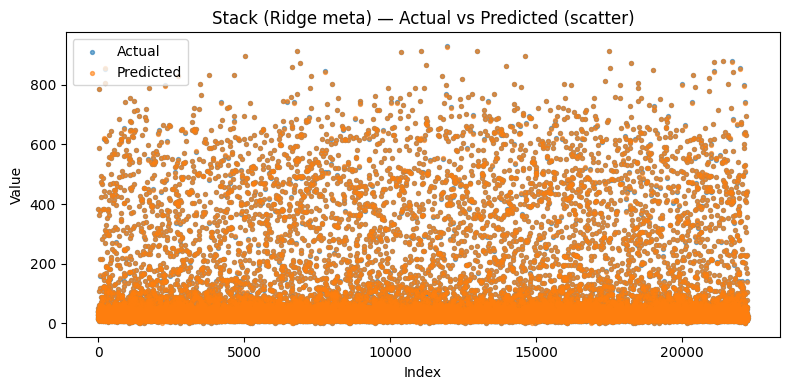


-- Stack (Linear meta): first few actual vs predicted --
    0: actual=14.000  pred=13.982  err=-0.018
    1: actual=21.000  pred=21.069  err=+0.069
    2: actual=41.000  pred=41.055  err=+0.055
    3: actual=36.000  pred=36.166  err=+0.166
    4: actual=16.000  pred=16.063  err=+0.063
    5: actual=36.000  pred=36.063  err=+0.063
    6: actual=31.000  pred=30.863  err=-0.137
    7: actual=29.000  pred=28.910  err=-0.090


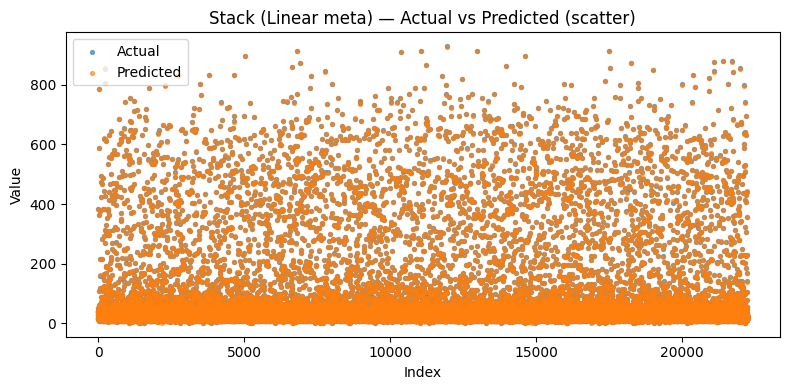


-- Stack (GBR meta): first few actual vs predicted --
    0: actual=14.000  pred=14.107  err=+0.107
    1: actual=21.000  pred=21.085  err=+0.085
    2: actual=41.000  pred=40.627  err=-0.373
    3: actual=36.000  pred=36.410  err=+0.410
    4: actual=16.000  pred=16.015  err=+0.015
    5: actual=36.000  pred=36.399  err=+0.399
    6: actual=31.000  pred=30.252  err=-0.748
    7: actual=29.000  pred=29.076  err=+0.076


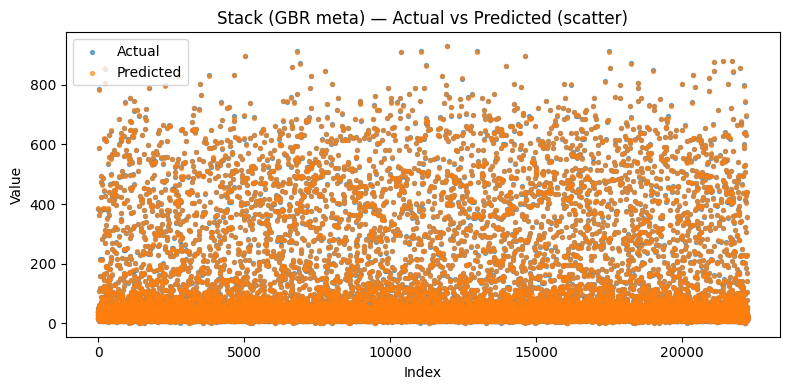

In [14]:
# ---- Top-3 by MAE, print + scatter visualization ----
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

# 1) Collect available ensemble predictions
ens_preds = {}
if 'pred_vote' in locals():         ens_preds['Voting (Top-3, equal)'] = pred_vote
if 'pred_stack_lin' in locals():    ens_preds['Stack (Linear meta)']   = pred_stack_lin
if 'pred_stack_ridge' in locals():  ens_preds['Stack (Ridge meta)']    = pred_stack_ridge
if 'pred_stack_gbr' in locals():    ens_preds['Stack (GBR meta)']      = pred_stack_gbr
if 'pred_avg' in locals():          ens_preds['Hybrid (Top-3 avg)']    = pred_avg

# 2) Rank by MAE (asc), then R2 (desc)
rows = [{"Model": name,
         "MAE": mean_absolute_error(y_te, yp),
         "R2":  r2_score(y_te, yp)} for name, yp in ens_preds.items()]
rank_df = (pd.DataFrame(rows)
             .sort_values(["MAE","R2"], ascending=[True, False])
             .reset_index(drop=True))

print("\n=== ENSEMBLES (ranked by MAE, then R2) ===")
print(rank_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

top3_names = rank_df["Model"].head(3).tolist()
print(f"\nTop-3: {top3_names}")

# 3) Print first few actual vs predicted for each top-3
def print_actual_pred(y_true, y_pred, k=8):
    k = min(k, len(y_true))
    for i in range(k):
        a, p = float(y_true[i]), float(y_pred[i])
        print(f"{i:>5}: actual={a:.3f}  pred={p:.3f}  err={p-a:+.3f}")

# 4) Two-color scatter (Actual vs Predicted over index)
def scatter_actual_pred_index(y_true, y_pred, title, sample=None, seed=42):
    x = np.arange(len(y_true))
    if sample is not None and len(x) > sample:
        rng = np.random.RandomState(seed)
        idx = rng.choice(len(x), size=sample, replace=False)
        x, y_true, y_pred = x[idx], y_true[idx], y_pred[idx]
    plt.figure(figsize=(8,4))
    plt.scatter(x, y_true, s=8, alpha=0.6, label="Actual")
    plt.scatter(x, y_pred, s=8, alpha=0.6, label="Predicted")
    plt.xlabel("Index"); plt.ylabel("Value"); plt.title(title)
    plt.legend(); plt.tight_layout(); plt.show()

for name in top3_names:
    yp = ens_preds[name]
    print(f"\n-- {name}: first few actual vs predicted --")
    print_actual_pred(y_te, yp, k=8)
    scatter_actual_pred_index(y_te, yp, f"{name} — Actual vs Predicted (scatter)", sample=100_000)


In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Load and process data
df = pd.read_csv("C://Users//israt//HD lab//My Project//Dataset//Airsage Dataset//NebraskaLakes_Cleaned_round.csv", low_memory=False) 
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d', errors='coerce')
df['day_of_week'] = df['date'].dt.dayofweek

# Keep only valid count values
df['count'] = pd.to_numeric(df['count'], errors='coerce')
df = df[df['count'] > 0].dropna(subset=['count'])

# ==== FEATURES: DO NOT CHANGE ====
features = [
    'day_of_week', 'duration', 'white', 'black', 'asian', 'native_american',
    'income_35_40', 'income_40_45', 'income_45_50'
]

# Keep only rows with valid values for selected features (+ meta so we can print later)
need_cols = features + ['count', 'poi_id', 'poi', 'date']
missing = [c for c in need_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df[need_cols].dropna()

# Remove outliers from features using IQR
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Split (keep meta to print POI/DATE with predictions)
df['date_str'] = df['date'].dt.strftime('%Y%m%d')
meta = df[['poi_id', 'poi', 'date_str']].reset_index(drop=True)

X = df[features].reset_index(drop=True)
y = df['count'].reset_index(drop=True)
X_train, X_test, y_train, y_test, m_train, m_test = train_test_split(
    X, y, meta, test_size=0.2, random_state=42
)

# Train model (same style)
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# Predict
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

# Evaluate
print("Train R² Score:", r2_score(y_train, y_train_pred))
print("Test  R² Score:", r2_score(y_test,  y_test_pred))
print("Test  MAE:", mean_absolute_error(y_test, y_test_pred))

# Show actual vs predicted for 20 test samples WITH POI id/name/date
print("\nVisit Count Prediction (Test Set):")
print("POI_ID | POI_NAME | DATE | Actual | Predicted")
for i in range(min(20, len(m_test))):
    poi_id = m_test.iloc[i]['poi_id']
    poi_nm = m_test.iloc[i]['poi']
    dstr   = m_test.iloc[i]['date_str']
    actual = int(round(y_test.iloc[i]))
    pred   = int(round(y_test_pred[i]))
    print(f"{poi_id} | {poi_nm} | {dstr} | {actual} | {pred}")


Train R² Score: 0.9349120058338086
Test  R² Score: 0.822115947149836
Test  MAE: 0.6802185935317686

Visit Count Prediction (Test Set):
POI_ID | POI_NAME | DATE | Actual | Predicted
5550.0 | Willard L Meyer Recreation Area | 20220122 | 14 | 15
5710.0 | Carter Lake | 20220313 | 19 | 20
4920.0 | Swanson Reservoir | 20220403 | 30 | 30
4565.0 | Lake Maloney | 20221030 | 25 | 25
5770.0 | Benson Lake | 20220413 | 15 | 14
6915.0 | Harlan County Reservoir (COE) | 20220626 | 16 | 16
4560.0 | Sutherland Reservoir | 20220402 | 7 | 8
6712.0 | Grand Island Suck's Lake | 20220709 | 17 | 17
4540.0 | Lake McConaughy | 20220922 | 17 | 16
3055.0 | Fremont 10 | 20221113 | 31 | 31
5710.0 | Carter Lake | 20220505 | 17 | 18
5485.0 | Wildwood | 20220525 | 12 | 12
6527.0 | Plum Creek Canyon | 20220412 | 13 | 13
5120.0 | Olive Creek | 20220918 | 16 | 17
3355.0 | Maple Creek Reservoir | 20221130 | 21 | 21
6530.0 | Elwood Reservoir | 20220511 | 10 | 10
3210.0 | Goose Lake | 20220529 | 16 | 17
3355.0 | Maple Creek